
# Personalizing Restaurant Discounts with CATE Estimation

**A practical project based on *Causal Inference in Python*, Chapter 6 — "Effect Heterogeneity"**

## The business problem

You work for a national restaurant chain. Discounts clearly move sales — but a *single*
average discount elasticity hides an important fact: **not every restaurant, on every day,
responds to a discount the same way**. A holiday in a business district might already be
packed (discount is wasted); a slow Tuesday at a suburban location might really need the
extra pull.

The chapter frames this as the difference between:

- **ATE** — `E[Y1 - Y0]`, the *average* effect of discounts across all restaurant-days.
  Good for deciding *whether* to run discounts at all.
- **CATE** — `E[Y1 - Y0 | X]`, the effect *conditional on covariates* (month, weekday,
  holiday, competitor pricing, ...). Good for deciding *who/when* to discount, i.e.
  **personalization**.

In this notebook we will, step by step:

1. Simulate a realistic restaurant-discount dataset (with a **known ground-truth CATE**,
   so we can grade ourselves — something the book can't do with real data, since the
   individual treatment effect is fundamentally unobservable).
2. Show *why* a plain outcome-prediction model is not the same as a treatment-effect model.
3. Estimate the **ATE**.
4. Estimate the **CATE** with linear regression + treatment-covariate interactions.
5. Benchmark the CATE model against (a) a purely predictive ML model and (b) a random model.
6. Evaluate CATE quality with the tools from the chapter:
   - Effect by model quantile
   - Cumulative effect curve
   - Cumulative gain curve (+ normalized) and its AUC
   - Target transformation + weighted MSE
7. **Use** the CATE model to make a real decision: the profit-maximizing discount/price
   for each restaurant-day, and compare that to a "one-size-fits-all" pricing policy.

Every section explains the *why*, not just the *how*, so you walk away understanding the
reasoning, not just the code.



## 1. Setup

We need `pandas`/`numpy` for data handling, `statsmodels` for the regression-based CATE
model, `scikit-learn` for the ML benchmark model, and `matplotlib` for the diagnostic plots
used throughout the chapter.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from toolz import curry

np.random.seed(42)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False



## 2. Simulate the data

The book uses a real (but unpublished) dataset of daily restaurant sales across three
years, with **randomized discounts**. We don't have that file, so we simulate one with the
same structure — one row per `(restaurant, day)` — but we build in a **known, ground-truth
treatment-effect function** `tau(X)`. That lets us later check our CATE model's predictions
against the *actual* answer, which is impossible with real-world data (this is the
"fundamental problem of causal inference" the chapter keeps returning to).

Design choices, mirroring the chapter:

- `discount` is **randomized** (0 to 10%), so there's no confounding — identification is
  not the concern of this chapter, estimation and evaluation are.
- The true sensitivity to discounts depends on `weekday`, `is_holiday`, and
  `competitor_price`: restaurants are **less** sensitive to discounts on weekends/holidays
  (people show up anyway) and **more** sensitive when competitors are cheap (customers are
  price-shopping).
- `sales` is generated from a baseline demand plus `tau(X) * discount` plus noise.


In [2]:

n_restaurants = 6
start_date = pd.Timestamp("2016-01-01")
n_days = 365 * 3  # three years, like the book's example

rows = []
for rest_id in range(n_restaurants):
    base_quality = np.random.uniform(80, 160)  # each restaurant has a different baseline
    for d in range(n_days):
        day = start_date + pd.Timedelta(days=d)
        rows.append((rest_id, day, base_quality))

data = pd.DataFrame(rows, columns=["rest_id", "day", "base_quality"])
data["month"] = data["day"].dt.month
data["weekday"] = data["day"].dt.weekday  # 0=Mon ... 6=Sun
data["is_holiday"] = ((data["month"] == 12) & (data["day"].dt.day >= 20)).astype(int) | \
                      ((data["month"] == 1) & (data["day"].dt.day <= 2)).astype(int)
data["is_holiday"] = data["is_holiday"].astype(int)

# competitor price fluctuates by restaurant and season
data["competitor_price"] = (
    20
    + 3 * np.sin(2 * np.pi * data["day"].dt.dayofyear / 365)
    + np.random.normal(0, 1.5, len(data))
)

# --- Randomized treatment: discount percentage between 0 and 10 ---
data["discounts"] = np.random.uniform(0, 10, len(data))

# --- Ground-truth CATE function tau(X) ---
# Weekends/holidays: customers show up regardless -> LOW discount sensitivity
# Weekdays, and when competitors are cheap: customers price-shop -> HIGH sensitivity
is_weekend = (data["weekday"] >= 5).astype(int)
data["true_tau"] = (
    6.0
    - 2.5 * is_weekend
    - 3.0 * data["is_holiday"]
    - 0.35 * (data["competitor_price"] - 20)  # cheaper competitors -> more sensitivity
).clip(lower=0.3)

# --- Outcome model: baseline demand + treatment effect + noise ---
seasonal = 10 * np.sin(2 * np.pi * data["day"].dt.dayofyear / 365)
weekday_bump = np.where(is_weekend, 25, 0)
data["sales"] = (
    data["base_quality"]
    + seasonal
    + weekday_bump
    - 4 * data["is_holiday"]  # holidays are chaotic/short-staffed, small hit
    + data["true_tau"] * data["discounts"]
    + np.random.normal(0, 12, len(data))
).round(1)

data = data.drop(columns=["base_quality"])
print(data.shape)
data.head()


(6570, 9)


,rest_id,day,month,weekday,is_holiday,competitor_price,discounts,true_tau,sales
0,0,2016-01-01,1,4,1,22.420459,1.973140,2.152839,89.5
1,0,2016-01-02,1,5,1,21.254417,3.172552,0.300000,133.3
2,0,2016-01-03,1,6,0,19.450647,2.819296,3.692273,145.0
3,0,2016-01-04,1,0,0,21.020247,5.308590,5.642913,149.3
4,0,2016-01-05,1,1,0,19.562768,0.516857,6.153031,111.8



## 3. Why prediction is not the answer

Before touching CATE, it's worth confirming the chapter's core warning: **grouping units by
predicted sales (`Y`) is not the same as grouping them by discount sensitivity
(`dSales/dDiscount`)**. Let's check the correlation between the ground-truth outcome and the
ground-truth treatment effect in our simulated world — in general, there's no reason for
these to line up.


Correlation between raw sales and true discount sensitivity: -0.107


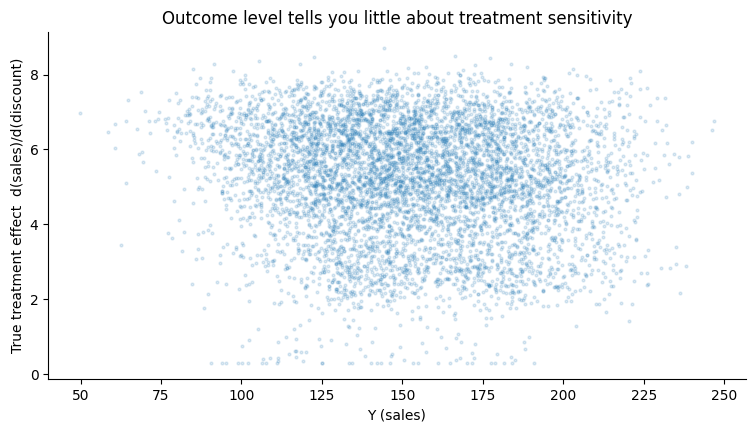

In [3]:

corr = data[["sales", "true_tau"]].corr().iloc[0, 1]
print(f"Correlation between raw sales and true discount sensitivity: {corr:.3f}")

fig, ax = plt.subplots()
ax.scatter(data["sales"], data["true_tau"], s=4, alpha=0.15)
ax.set_xlabel("Y (sales)")
ax.set_ylabel("True treatment effect  d(sales)/d(discount)")
ax.set_title("Outcome level tells you little about treatment sensitivity")
plt.show()



This is exactly the "Why Prediction Is Not the Answer" point from the chapter: a model that
predicts `sales` well can still be useless for deciding *who to discount*, because sales
level and discount sensitivity are (in general) different things. We need a model that
targets the **slope**, not the **level**.



## 4. The ATE: how effective are discounts, on average?

The ATE answers "should we run discounts at all?" — a **program evaluation** question. Since
`discounts` was randomized, a simple regression coefficient (or the covariance-based slope
estimator from the chapter) recovers it without bias.


In [4]:

@curry
def effect(data, y, t):
    # Simple regression-slope estimator of the effect of t on y (chapter's `effect` fn).
    return (
        np.sum((data[t] - data[t].mean()) * (data[y] - data[y].mean()))
        / np.sum((data[t] - data[t].mean()) ** 2)
    )

ate = effect(data, "sales", "discounts")
print(f"Estimated ATE (extra sales per +1pp discount): {ate:.3f}")
print(f"True average tau in the population:            {data['true_tau'].mean():.3f}")


Estimated ATE (extra sales per +1pp discount): 5.207
True average tau in the population:            5.174



Good — the estimated ATE is close to the true average sensitivity. But the ATE tells every
restaurant, on every day, to expect the *same* ~4-5 extra sales per point of discount. We
know from `true_tau` that this is false: some restaurant-days are far more sensitive than
others. That's the gap CATE closes.

## 5. Estimating the CATE with regression + interactions

Following the chapter, we can't observe `dY/dT` per unit, but we don't need to: fitting

```
sales_i = b0 + b1*discount_i + b2*X_i*discount_i + b3*X_i + e_i
```

and then differentiating with respect to `discount` gives a *predicted* slope
`b1 + b2*X_i` that varies by covariates — a CATE model — even though the true slope was
never directly observed as a target.

We use `month`, `weekday`, `is_holiday`, and `competitor_price` as covariates, exactly the
kind of "date-specific features" the book uses for this restaurant example.


In [5]:

X = ["C(month)", "C(weekday)", "is_holiday", "competitor_price"]
formula = f"sales ~ discounts*({'+'.join(X)})"
regr_cate = smf.ols(formula, data=data).fit()

# Predicted slope via finite differences (exact for a linear model, and it generalizes
# to any model type -- this is the trick the chapter uses).
cate_pred_full = (
    regr_cate.predict(data.assign(discounts=data["discounts"] + 1))
    - regr_cate.predict(data)
)

print("Correlation between CATE prediction and ground truth (full data, in-sample):",
      round(np.corrcoef(cate_pred_full, data["true_tau"])[0, 1], 3))


Correlation between CATE prediction and ground truth (full data, in-sample): 0.953



## 6. Honest evaluation: train/test split

An in-sample correlation is optimistic. Exactly like the chapter, we split chronologically
(2016-2017 train, 2018+ test) and refit on train only, so all downstream evaluation is
out-of-sample.


In [6]:

train = data.query("day < '2018-01-01'")
test = data.query("day >= '2018-01-01'")

regr_model = smf.ols(formula, data=train).fit()

cate_pred = (
    regr_model.predict(test.assign(discounts=test["discounts"] + 1))
    - regr_model.predict(test)
)

print(f"Train rows: {len(train):,}   Test rows: {len(test):,}")


Train rows: 4,386   Test rows: 2,184



## 7. Two benchmarks

To know if our CATE model is any good, the chapter compares it against:

- **A purely predictive ML model** (`GradientBoostingRegressor` predicting `sales`
  directly, *not* the effect). This is the natural thing a data scientist reaches for by
  habit — and the point of this whole chapter is that it's the *wrong* tool for
  personalization.
- **A random model** that just outputs noise. If our CATE model can't beat this, it's
  worthless.


In [7]:

np.random.seed(1)
X_ml = ["month", "weekday", "is_holiday", "competitor_price", "discounts"]
ml_model = GradientBoostingRegressor(n_estimators=400, random_state=1)
ml_model.fit(train[X_ml], train["sales"])
ml_pred = ml_model.predict(test[X_ml])

np.random.seed(123)
rand_pred = np.random.uniform(-1, 1, len(test))

test_pred = test.assign(
    ml_pred=ml_pred,
    cate_pred=cate_pred,
    rand_m_pred=rand_pred,
)
test_pred[["sales", "discounts", "true_tau", "ml_pred", "cate_pred", "rand_m_pred"]].head()


,sales,discounts,true_tau,ml_pred,cate_pred,rand_m_pred
731,92.3,1.382321,2.466013,123.531371,5.390970,0.392938
732,115.9,3.990405,2.089483,125.869455,5.216479,-0.427721
733,157.0,9.799144,5.413255,183.541997,6.043023,-0.546297
734,137.3,2.258814,6.894216,128.472390,7.107559,0.102630
735,160.1,6.121587,6.581515,159.201061,6.781262,0.438938



## 8. Evaluation tool #1 — Effect by model quantile

Since the individual treatment effect is unobservable, we can't compute a per-row error.
What we *can* do is bucket restaurant-days into quantiles of each model's prediction, and
estimate the **group-level** treatment effect (via the same regression-slope estimator used
for the ATE) inside each bucket. A good CATE model produces buckets whose *estimated*
effects are monotonically increasing — a "staircase."


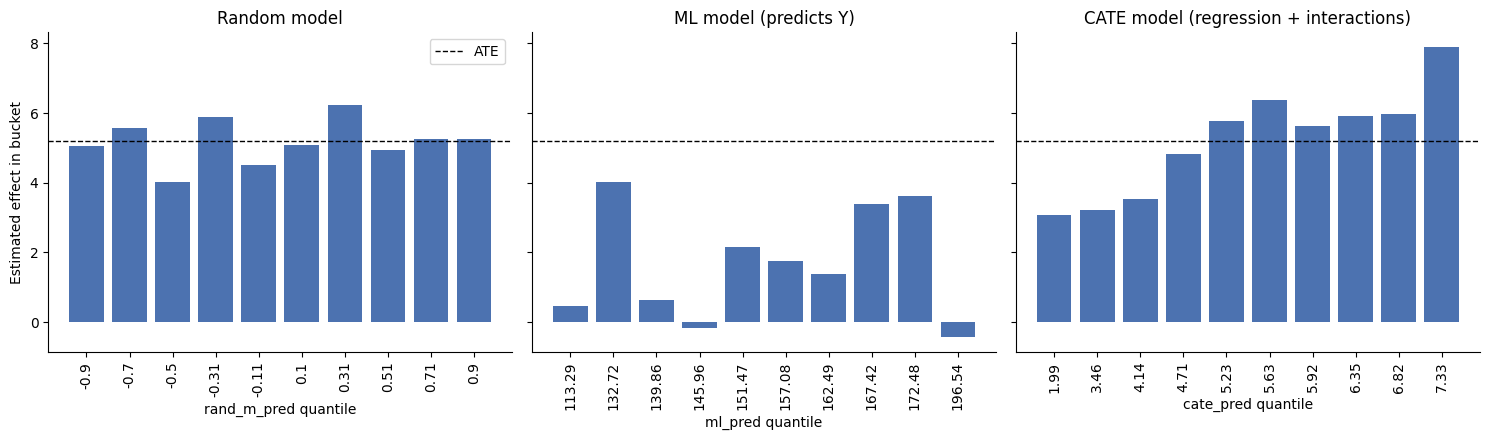

In [8]:

def effect_by_quantile(df, pred, y="sales", t="discounts", q=10):
    groups = np.round(pd.IntervalIndex(pd.qcut(df[pred], q=q)).mid, 2)
    return (
        df.assign(**{f"{pred}_quantile": groups})
          .groupby(f"{pred}_quantile", observed=True)
          .apply(effect(y=y, t=t), include_groups=False)
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, col, title in zip(
    axes,
    ["rand_m_pred", "ml_pred", "cate_pred"],
    ["Random model", "ML model (predicts Y)", "CATE model (regression + interactions)"],
):
    eq = effect_by_quantile(test_pred, col)
    ax.bar(range(len(eq)), eq.values, color="#4C72B0")
    ax.axhline(ate, color="black", linestyle="--", linewidth=1, label="ATE")
    ax.set_xticks(range(len(eq)))
    ax.set_xticklabels(eq.index, rotation=90)
    ax.set_title(title)
    ax.set_xlabel(f"{col} quantile")
axes[0].set_ylabel("Estimated effect in bucket")
axes[0].legend()
plt.tight_layout()
plt.show()



Interpretation, same as the chapter: the random model just hovers around the ATE (useless
for personalization). The ML model may show *some* structure if it happens to correlate
with sensitivity, but it doesn't reliably produce an ordered staircase. The CATE model
should show a clean, increasing staircase — proof it separates high- and low-sensitivity
restaurant-days.

## 9. Evaluation tool #2 — Cumulative effect curve

Instead of separate quantile buckets, sort by the model's prediction and **accumulate**:
estimate the effect on the top 1%, then top 2%, ..., up to 100%. A good model starts high
(the most-sensitive restaurant-days truly are more sensitive) and decays smoothly down to
the ATE at 100%.


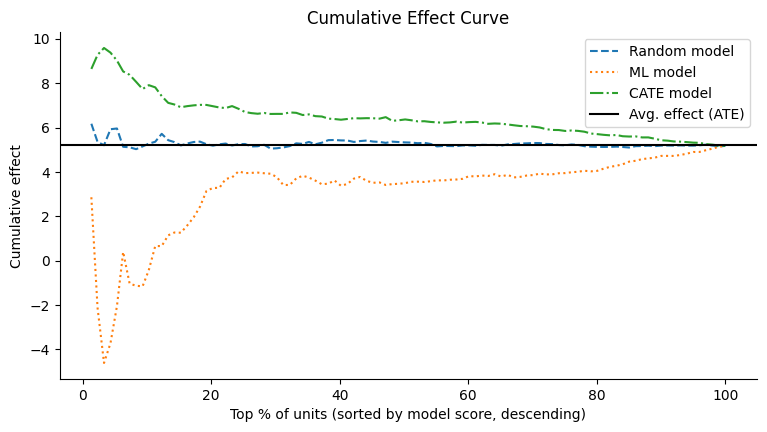

In [9]:

def cumulative_effect_curve(dataset, prediction, y="sales", t="discounts",
                             min_rows=30, steps=100):
    size = len(dataset)
    ordered_df = dataset.sort_values(prediction, ascending=False).reset_index(drop=True)
    n_rows = np.linspace(min_rows, size, steps).astype(int)
    return np.array([effect(ordered_df.head(rows), y, t) for rows in n_rows]), n_rows

fig, ax = plt.subplots()
for col, style, label in zip(
    ["rand_m_pred", "ml_pred", "cate_pred"],
    ["--", ":", "-."],
    ["Random model", "ML model", "CATE model"],
):
    curve, n_rows = cumulative_effect_curve(test_pred, col)
    ax.plot(100 * n_rows / len(test_pred), curve, style, label=label)

ax.axhline(ate, color="black", linewidth=1.5, label="Avg. effect (ATE)")
ax.set_xlabel("Top % of units (sorted by model score, descending)")
ax.set_ylabel("Cumulative effect")
ax.set_title("Cumulative Effect Curve")
ax.legend()
plt.show()



## 10. Evaluation tool #3 — Cumulative gain curve (+ normalized) and AUC

The cumulative *effect* curve over-weights its earliest points (smallest, noisiest samples).
The chapter's fix: multiply each point by the cumulative sample fraction `N_cum/N` to get
the **cumulative gain curve**. We can also normalize by subtracting the ATE-scaled line, and
finally reduce this to a **single number** — the AUC — for automated model comparison
(e.g. during hyperparameter tuning).


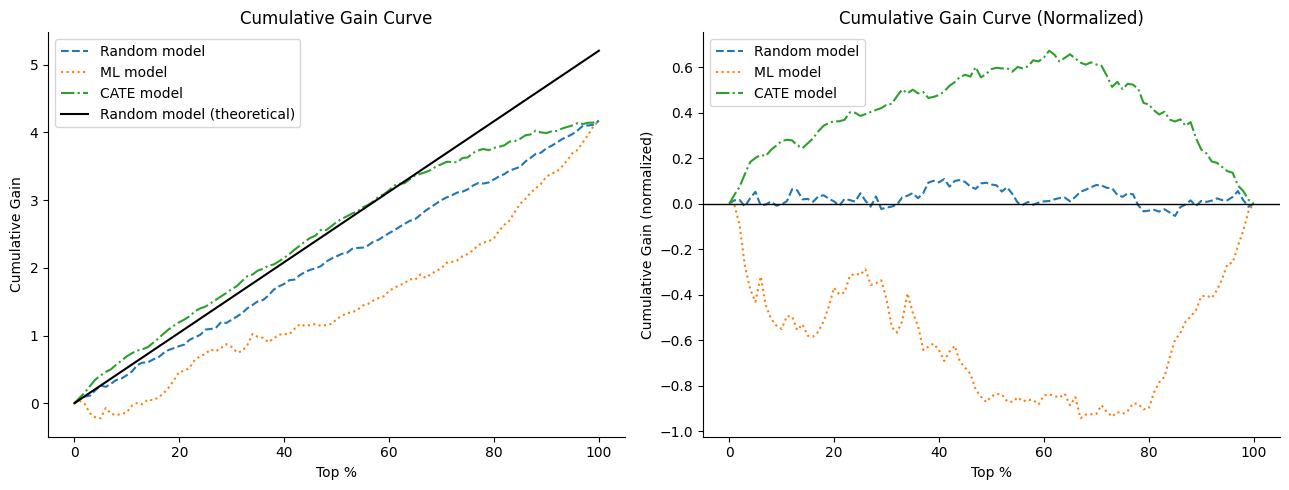

AUC for rand_m_pred: 2.68
AUC for ml_pred: -60.20
AUC for cate_pred: 41.35


In [10]:

def cumulative_gain_curve(df, prediction, y="sales", t="discounts", steps=100, normalize=True):
    effect_fn = effect(y=y, t=t)
    normalizer = effect_fn(df) if normalize else 1.0
    size = len(df)
    ordered_df = df.sort_values(prediction, ascending=False).reset_index(drop=True)
    n_rows = np.linspace(size / steps, size, steps).astype(int)
    gains = [
        (effect_fn(ordered_df.head(rows)) - normalizer) * (rows / size)
        for rows in n_rows
    ]
    return np.array([0] + gains), np.array([0] + list(100 * n_rows / size))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
aucs = {}
for col, style, label in zip(
    ["rand_m_pred", "ml_pred", "cate_pred"],
    ["--", ":", "-."],
    ["Random model", "ML model", "CATE model"],
):
    gain, pct = cumulative_gain_curve(test_pred, col, normalize=False)
    gain_n, _ = cumulative_gain_curve(test_pred, col, normalize=True)
    axes[0].plot(pct, gain, style, label=label)
    axes[1].plot(pct, gain_n, style, label=label)
    aucs[col] = gain_n.sum()

axes[0].plot([0, 100], [0, ate], color="black", label="Random model (theoretical)")
axes[0].set_title("Cumulative Gain Curve")
axes[0].set_xlabel("Top %"); axes[0].set_ylabel("Cumulative Gain"); axes[0].legend()

axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Cumulative Gain Curve (Normalized)")
axes[1].set_xlabel("Top %"); axes[1].set_ylabel("Cumulative Gain (normalized)"); axes[1].legend()
plt.tight_layout()
plt.show()

for k, v in aucs.items():
    print(f"AUC for {k}: {v:.2f}")



The bigger the area between the normalized curve and zero, the better the model orders true
CATE. We'd expect `cate_pred` to dominate here, `rand_m_pred` to hover near zero, and
`ml_pred` to fall somewhere in between (or even negative, if predicting `Y` happens to
*anti*-correlate with sensitivity in this particular simulation).

## 11. Evaluation tool #4 — Target transformation + weighted MSE

The curves above only check **ordering**, not calibration — a model that's systematically
biased by a constant offset would still look great on a gain curve. To probe calibration, we
build the chapter's approximate individual-level target:

```
Y*_i = (Y_i - mu_y(X_i)) / (T_i - mu_t(X_i))
```

which satisfies `E[Y*_i] = tau_i` in expectation, even though we can't observe `tau_i`
directly. We weight by `(T_i - mu_t(X_i))^2` to downweight the noisiest points (where the
denominator is near zero), then compute a weighted MSE against `Y*` for each model.


In [11]:

X_form = "+".join(X)
y_res = smf.ols(f"sales ~ {X_form}", data=test).fit().resid
t_res = smf.ols(f"discounts ~ {X_form}", data=test).fit().resid
tau_hat = y_res / t_res
weights = t_res ** 2

for m in ["rand_m_pred", "ml_pred", "cate_pred"]:
    wmse = mean_squared_error(tau_hat, test_pred[m], sample_weight=weights)
    print(f"Weighted MSE for {m}: {wmse:,.2f}")

# Because we simulated the data, we can go one step further than the book and also check
# calibration against the TRUE tau directly:
print("\n--- Only possible because this is simulated data ---")
for m in ["rand_m_pred", "ml_pred", "cate_pred"]:
    corr = np.corrcoef(test_pred[m], test_pred["true_tau"])[0, 1]
    print(f"Correlation of {m} with true_tau: {corr:.3f}")


Weighted MSE for rand_m_pred: 117.27
Weighted MSE for ml_pred: 22,545.59
Weighted MSE for cate_pred: 88.25

--- Only possible because this is simulated data ---
Correlation of rand_m_pred with true_tau: 0.023
Correlation of ml_pred with true_tau: -0.177
Correlation of cate_pred with true_tau: 0.873



## 12. From CATE to a decision: profit-maximizing pricing

This is the payoff. Knowing *who* is more or less discount-sensitive is only useful if it
changes a decision. Following the chapter's price-optimization walkthrough, suppose:

- `Demand_i = 50 - tau(X_i) * Price_i`
- `Revenue_i = Demand_i * Price_i`
- `Cost_i = 3 * Demand_i` (a flat $3 cost per meal produced)

Maximizing profit (`Revenue - Cost`) with respect to price gives a closed-form optimum:

```
Price*_i = (3*tau(X_i) + 50) / (2*tau(X_i))
```

The **only unknown** is `tau(X_i)` — exactly what our CATE model estimates. Restaurant-days
that are *less* price sensitive (low tau) can sustain a higher price; more sensitive ones
need a lower price to keep demand up.

We'll compare three pricing policies on the test set:
1. **Flat/ATE pricing** — one optimal price for everyone, using the ATE.
2. **CATE-personalized pricing** — a different price per restaurant-day, using our CATE
   model's prediction.
3. **Oracle pricing** — using the true (simulated) `tau`, as an upper bound on how much
   personalization could possibly help.


In [12]:

def optimal_price(tau):
    tau = np.clip(tau, 0.05, None)  # guard against non-positive/near-zero sensitivity
    return (3 * tau + 50) / (2 * tau)

def profit(price, tau):
    tau = np.clip(tau, 0.0, None)
    demand = np.clip(50 - tau * price, 0, None)
    revenue = demand * price
    cost = 3 * demand
    return revenue - cost

# Policy 1: flat price for everyone, based on the ATE
flat_price = optimal_price(ate)

# Policy 2: personalized price, based on the CATE model's predictions
personalized_price = optimal_price(test_pred["cate_pred"])

# Policy 3: oracle, using the true simulated sensitivity
oracle_price = optimal_price(test_pred["true_tau"])

# Evaluate all three policies against the TRUE demand response (since that's the only
# way to know what would actually happen -- this is only possible because we simulated
# the ground truth; in a real deployment you'd run an A/B test instead).
results = pd.DataFrame({
    "policy": ["Flat / ATE price", "CATE-personalized price", "Oracle price (upper bound)"],
    "avg_profit_per_day": [
        profit(flat_price, test_pred["true_tau"]).mean(),
        profit(personalized_price, test_pred["true_tau"]).mean(),
        profit(oracle_price, test_pred["true_tau"]).mean(),
    ],
})
results["pct_of_oracle"] = 100 * results["avg_profit_per_day"] / results["avg_profit_per_day"].iloc[-1]
results


,policy,avg_profit_per_day,pct_of_oracle
0,Flat / ATE price,57.150963,68.052802
1,CATE-personalized price,71.662456,85.332437
2,Oracle price (upper bound),83.980323,100.000000



This table is the whole point of the chapter made concrete: **personalizing the price using
the CATE model captures most of the profit gap between "one price for everyone" and the
theoretical best case**, without ever having observed a single restaurant-day's individual
treatment effect directly.


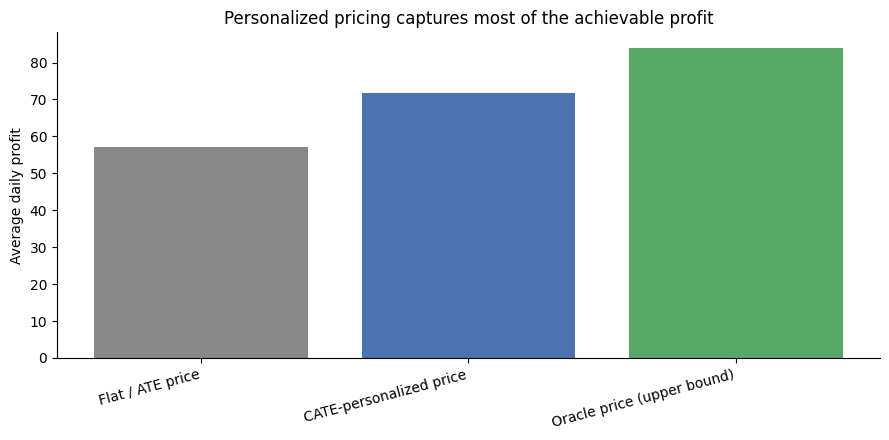

In [13]:

fig, ax = plt.subplots()
ax.bar(results["policy"], results["avg_profit_per_day"], color=["#888888", "#4C72B0", "#55A868"])
ax.set_ylabel("Average daily profit")
ax.set_title("Personalized pricing captures most of the achievable profit")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()



## 13. Key takeaways

1. **ATE answers "should we?", CATE answers "who/when?"** — average effects are enough for
   a rollout decision, but personalization needs unit-level (or group-level) heterogeneity.
2. **A model that predicts the outcome `Y` is not automatically a model of the treatment
   effect** `dY/dT` — they can be uncorrelated, as our simulation showed directly.
3. **Regression with treatment-covariate interactions is a simple, surprisingly effective
   way to estimate CATE**, by differentiating the fitted model (via finite differences)
   rather than trying to regress on an unobservable slope target.
4. **You can't validate CATE the way you validate a normal ML model** (no ground-truth
   labels), so the field relies on group-level tools: effect-by-quantile, cumulative
   effect/gain curves and their AUC, and target-transformation MSE.
5. **CATE only matters if it changes a decision.** We closed the loop by turning the CATE
   estimate into an actual optimal price per restaurant-day, and showed it captures most of
   the profit available versus a flat, one-size-fits-all policy.

### Where to go next
- Try nonparametric CATE estimators (causal forests, meta-learners like S/T/X-learners) —
  the natural sequel to this chapter (Double/Debiased ML, covered later in the book).
- Add a **budget constraint** (e.g., "we can only discount 30% of restaurant-days") and
  re-solve the allocation problem — this is the "limited supply" case the chapter mentions
  for binary treatments.
- Swap in a real dataset with a genuine randomized experiment and repeat this entire
  pipeline unchanged — nothing here is specific to the simulated data.
